# Comparativa Global de Algoritmos de Aprendizaje por Refuerzo en Entornos Complejos

Este notebook realiza una comparación exhaustiva entre algoritmos de **Monte Carlo** y **Diferencia Temporal (TD)** aplicados al entorno **FrozenLake 4x4**.

El objetivo es analizar y visualizar el rendimiento de los siguientes algoritmos:
1.  **Monte Carlo On-Policy (First Visit & Every Visit)**: Métodos de control Monte Carlo on-policy.
2.  **Monte Carlo Off-Policy (Weighted Importance Sampling)**: Método de control Monte Carlo off-policy utilizando muestreo por importancia ponderado.
3.  **SARSA**: Algoritmo de control TD On-Policy (State-Action-Reward-State-Action).
4.  **Q-Learning**: Algoritmo de control TD Off-Policy.
5.  **Double Q-Learning**: Variante de Q-Learning diseñada para reducir la sobreestimación de los valores de acción.

Se evaluarán dos métricas principales:
*   **Proporción de Recompensa (Success Rate)**: Evolución del retorno promedio acumulado.
*   **Longitud de Episodios**: Número de pasos necesarios para completar cada episodio.

In [9]:
# Importamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import random
import torch
import gc
import os
import sys

# Aseguramos que el directorio raíz está en el path para importar módulos locales
sys.path.append(os.getcwd())

# Importamos las clases de los agentes desde src
# Monte Carlo
from src.agents.AgenteMC_OnPolicy import AgenteMC_OnPolicy
from src.agents.AgenteMC_OffPolicy import AgenteMC_OffPolicy

# Diferencia Temporal
from src.agents.AgenteDT_Sarsa import AgenteDT_Sarsa
from src.agents.AgenteDT_QL import AgenteDT_QL
from src.agents.AgenteDT_Double_QL import AgenteDT_Double_QL

# Metodos Aproximados (Aunque no los usaremos para entrenamiento, los dejamos si luego se requieren)
from src.agents.AgenteDT_SarsaSG import AgenteDT_SarsaSG
from src.agents.AgenteDT_Deep_QL import AgenteDT_DeepQL
from src.agents.AgenteDT_Double_Deep_QL import AgenteDT_DobleDeepQL
from src.tilings.tiling import TileCodingEnv

from src.ploting import *

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria
gc.collect()
torch.cuda.empty_cache()

# Configuración de la semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
np.random.default_rng(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Usando dispositivo: cpu


In [3]:
# Configuración del Entorno FrozenLake 4x4
# Usamos map_name="4x4" y is_slippery=False para un entorno determinista y más fácil de analizar.
# El argumento is_slippery=False hace que las transiciones sean deterministas (siempre va a donde quieres).
name_env = 'FrozenLake-v1'
render = "rgb_array"
# Establecemos un límite de pasos razonable para evitar bucles infinitos en políticas iniciales
env_4x4 = gym.make(name_env, is_slippery=False, map_name="4x4", render_mode=render, max_episode_steps=500)
env_8x8 = gym.make(name_env, is_slippery=False, map_name="8x8", render_mode=render, max_episode_steps=500) # Más pasos para 8x8
print("Entornos FrozenLake 4x4 y 8x8 (is_slippery=False) inicializados.")

Entornos FrozenLake 4x4 y 8x8 (is_slippery=False) inicializados.


In [4]:
# Funciones de Ejecución para Monte Carlo

def monte_carlo_all_visit(env, agente, num_episodes=5000):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), desc="MC All Visit"):
        state, info = env.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            result_sum += reward
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            state = new_state

        # Fase de actualización: Iteramos en orden inverso (delegado al agente)
        agente.update(episode)    
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

    return list_stats, all_episode_lengths

def monte_carlo_first_visit(env, agente, num_episodes=5000):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    num_goal = 0

    for t in tqdm(range(num_episodes), desc="MC First Visit"):
        state, info = env.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            if reward == 1.0:
                num_goal += 1
            # Guardamos el estado, la acción y la recompensa
            result_sum += reward
            episode.append((state, action, reward))
            state = new_state

        # Primera visita (delegado al agente)
        agente.update_first_visit(episode)    
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

    return list_stats, all_episode_lengths

In [5]:
# Función de Ejecución para Diferencia Temporal (Sarsa / Q-Learning)

def diferencia_temporal(env, agente, num_episodes=5000, label="TD"):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), desc=label):
        state, info = env.reset(seed=seed)
        done = False
        result_sum  = 0.0
        steps = 0
        
        # Obtenemos acción inicial (necesaria para SARSA)
        action = agente.get_action(state, t)
        
        while not done:
            new_state, reward, terminated, truncated, info = env.step(action)
            # Obtenemos siguiente acción (para SARSA; Q-Learning ignorará esto en su update interno)
            new_action = agente.get_action(new_state, t)

            done = terminated or truncated
            
            # Actualizamos el agente
            # Nota: Para Q-Learning 'new_action' no se usa realmente en la fórmula de update, 
            # pero se pasa por compatibilidad de interfaz si la función es genérica.
            agente.update(state, action, reward, new_state, new_action, done)
            
            result_sum += reward
            state = new_state
            action = new_action
            steps += 1

        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(steps)

    return list_stats, all_episode_lengths

# Función de Ejecución para Métodos Aproximados (SarsaSG / Deep Q-Learning)
def entrenamientoDeepQL(tcenv, agente, num_episodes=5000, target_update_freq=500):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    
    global_step = 0 # Añadimos un contador global de pasos
    
    for t in tqdm(range(num_episodes)):
        # Asumo que `seed` está definida globalmente en tu script
        state, info = tcenv.reset(seed=seed) 
        done = False
        episode = []
        result_sum  = 0.0
        c = 0
        
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, _ = tcenv.step(action)
            done = truncated or terminated
            
            # Guardamos la experiencia
            episode.append((state, action, reward))
            agente.save_experience(state, action, reward, new_state, done)
            
            # --- EL CAMBIO CRÍTICO: ENTRENAR DENTRO DEL BUCLE ---
            # Ahora la red aprende en cada paso (o cuando el batch tenga tamaño suficiente)
            agente.update()
            
            # --- ACTUALIZACIÓN DE RED OBJETIVO POR PASOS ---
            if global_step % target_update_freq == 0 and global_step > 0:
                agente.update_target_network()
            
            result_sum += reward
            state = new_state
            c += 1
            global_step += 1
            
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")

    return list_stats, all_episode_lengths

In [6]:
# Función para ejecutar todos los experimentos en un entorno dado
def ejecutar_experimentos(env, env_name, params):
    # Extraemos parámetros generales
    num_episodes = params.get('num_episodes', 5000)
    
    # Diccionario para guardar resultados
    results = {}

    print(f"\n--- Iniciando experimentos para {env_name} ---")

    # 1. Monte Carlo On-Policy (All Visit)
    if 'MC_All_Visit' in params:
        p = params['MC_All_Visit']
        print(f"[{env_name}] Entrenando MC All Visit...")
        agente_mc_all = AgenteMC_OnPolicy(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 1.0), 
            decay=p.get('decay', True)
        )
        stats_mc_all, lengths_mc_all = monte_carlo_all_visit(env, agente_mc_all, num_episodes)
        results['MC All Visit'] = {'stats': stats_mc_all, 'lengths': lengths_mc_all}

    # 2. Monte Carlo On-Policy (First Visit)
    if 'MC_First_Visit' in params:
        p = params['MC_First_Visit']
        print(f"[{env_name}] Entrenando MC First Visit...")
        agente_mc_first = AgenteMC_OnPolicy(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 1.0), 
            decay=p.get('decay', True)
        )
        stats_mc_first, lengths_mc_first = monte_carlo_first_visit(env, agente_mc_first, num_episodes)
        results['MC First Visit'] = {'stats': stats_mc_first, 'lengths': lengths_mc_first}

    # 3. Monte Carlo Off-Policy (Weighted Importance Sampling)
    if 'MC_Off_Policy' in params:
        p = params['MC_Off_Policy']
        print(f"[{env_name}] Entrenando MC Off-Policy...")
        agente_mc_off = AgenteMC_OffPolicy(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True)
        )
        stats_mc_off, lengths_mc_off = monte_carlo_all_visit(env, agente_mc_off, num_episodes)
        results['MC Off-Policy'] = {'stats': stats_mc_off, 'lengths': lengths_mc_off}

    # 4. SARSA
    if 'SARSA' in params:
        p = params['SARSA']
        print(f"[{env_name}] Entrenando SARSA...")
        agente_sarsa = AgenteDT_Sarsa(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True), 
            decay_rate=p.get('decay_rate', 4000.0)
        )
        stats_sarsa, lengths_sarsa = diferencia_temporal(env, agente_sarsa, num_episodes, label="SARSA")
        results['SARSA'] = {'stats': stats_sarsa, 'lengths': lengths_sarsa}

    # 5. Q-Learning
    if 'Q_Learning' in params:
        p = params['Q_Learning']
        print(f"[{env_name}] Entrenando Q-Learning...")
        agente_ql = AgenteDT_QL(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True), 
            decay_rate=p.get('decay_rate', 500.0)
        )
        stats_ql, lengths_ql = diferencia_temporal(env, agente_ql, num_episodes, label="Q-Learning")
        results['Q-Learning'] = {'stats': stats_ql, 'lengths': lengths_ql}

    # 6. Double Q-Learning
    if 'Double_Q_Learning' in params:
        p = params['Double_Q_Learning']
        print(f"[{env_name}] Entrenando Double Q-Learning...")
        agente_dql = AgenteDT_Double_QL(
            env, seed, 
            num_episodes=num_episodes, 
            epsilon=p.get('epsilon', 0.4), 
            discount_factor=p.get('discount_factor', 0.9), 
            decay=p.get('decay', True), 
            decay_rate=p.get('decay_rate', 500.0)
        )
        stats_dql, lengths_dql = diferencia_temporal(env, agente_dql, num_episodes, label="Double Q-Learning")
        results['Double Q-Learning'] = {'stats': stats_dql, 'lengths': lengths_dql}
    
    return results

# Definición de parámetros para 4x4
params_4x4 = {
    'num_episodes': 10000,
    'MC_All_Visit': {'epsilon': 0.4, 'discount_factor': 0.99, 'decay': True, 'decay_rate': 1000.0},
    'MC_Off_Policy': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 1000.0},
    'SARSA': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 1000.0},
    'Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0},
    'Double_Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0}
}
# Nota: Puedes agregar 'MC_First_Visit' al diccionario si deseas ejecutarlo.

# Ejecutamos experimentos para 4x4
results_4x4 = ejecutar_experimentos(env_4x4, "FrozenLake 4x4", params_4x4)

# Definición de parámetros para 8x8
params_8x8 = {
    'num_episodes': 30000,
    'MC_All_Visit': {'epsilon': 0.4, 'discount_factor': 0.99, 'decay': True, 'decay_rate': 1000.0},
    'MC_Off_Policy': {'epsilon': 0.4, 'discount_factor': 0.99, 'decay': True, 'decay_rate': 1000.0},
    'SARSA': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 4000.0},
    'Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0},
    'Double_Q_Learning': {'epsilon': 0.4, 'discount_factor': 0.9, 'decay': True, 'decay_rate': 500.0}
}

# Ejecutamos experimentos para 8x8
results_8x8 = ejecutar_experimentos(env_8x8, "FrozenLake 8x8", params_8x8)


--- Iniciando experimentos para FrozenLake 4x4 ---
[FrozenLake 4x4] Entrenando MC All Visit...


MC All Visit: 100%|██████████| 10000/10000 [00:05<00:00, 1803.08it/s]


[FrozenLake 4x4] Entrenando MC Off-Policy...


MC All Visit: 100%|██████████| 10000/10000 [00:04<00:00, 2409.70it/s]


[FrozenLake 4x4] Entrenando SARSA...


...

SARSA: 100%|██████████| 30000/30000 [00:28<00:00, 1055.71it/s]


[FrozenLake 8x8] Entrenando Q-Learning...


Q-Learning: 100%|██████████| 30000/30000 [00:37<00:00, 792.95it/s]


[FrozenLake 8x8] Entrenando Double Q-Learning...


Double Q-Learning: 100%|██████████| 30000/30000 [00:41<00:00, 727.84it/s]


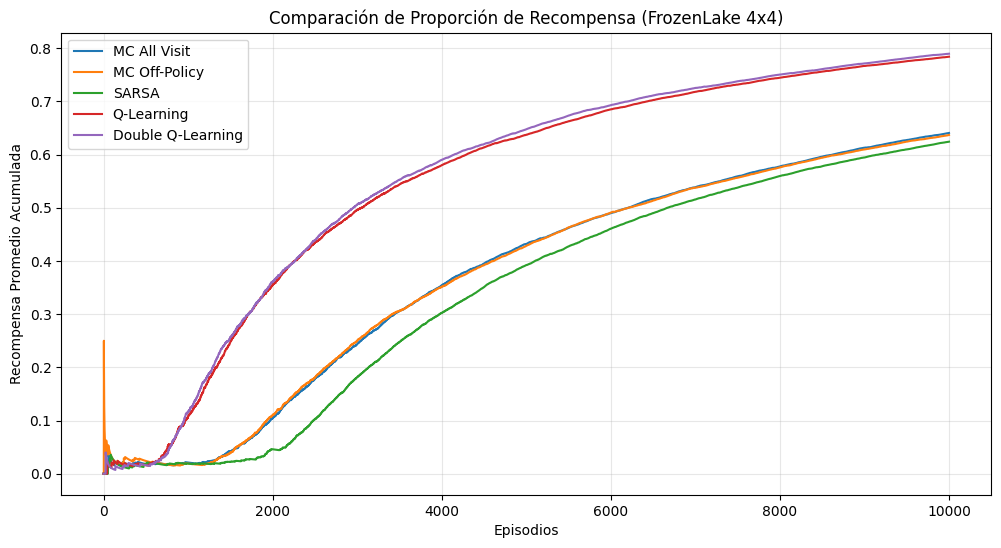

Rendimiento final (Promedio Acumulado) - FrozenLake 4x4:
MC All Visit: 0.6408
MC Off-Policy: 0.6370
SARSA: 0.6244
Q-Learning: 0.7842
Double Q-Learning: 0.7898


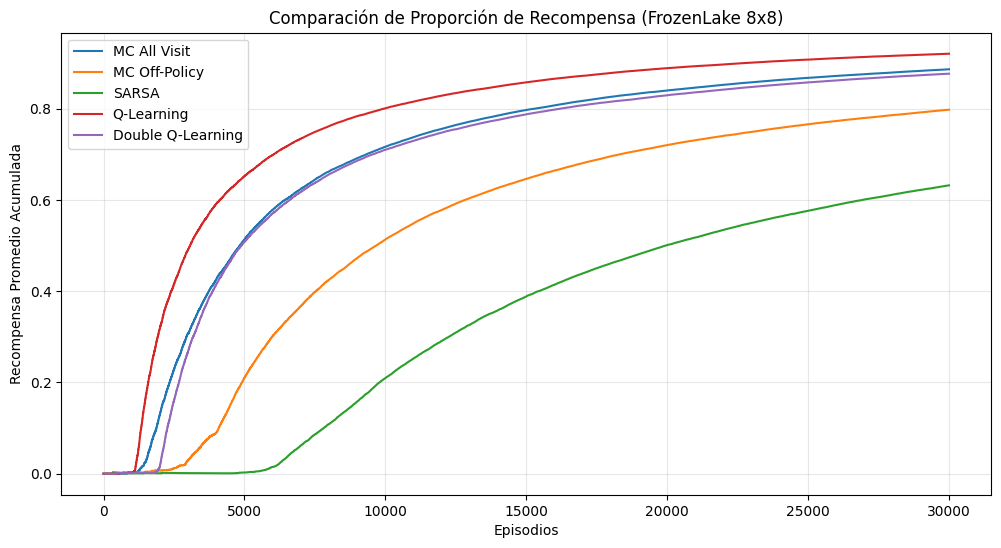

Rendimiento final (Promedio Acumulado) - FrozenLake 8x8:
MC All Visit: 0.8867
MC Off-Policy: 0.7980
SARSA: 0.6322
Q-Learning: 0.9208
Double Q-Learning: 0.8770


In [7]:
# Función de visualización de Recompensas
def plot_rewards(results, title_suffix):
    plt.figure(figsize=(12, 6))

    for name, data in results.items():
        stats = data['stats']
        plt.plot(stats, label=name)

    plt.xlabel('Episodios')
    plt.ylabel('Recompensa Promedio Acumulada')
    plt.title(f'Comparación de Proporción de Recompensa ({title_suffix})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Imprimir valores finales
    print(f"Rendimiento final (Promedio Acumulado) - {title_suffix}:")
    for name, data in results.items():
        print(f"{name}: {data['stats'][-1]:.4f}")

# Plot 4x4
plot_rewards(results_4x4, "FrozenLake 4x4")

# Plot 8x8
plot_rewards(results_8x8, "FrozenLake 8x8")

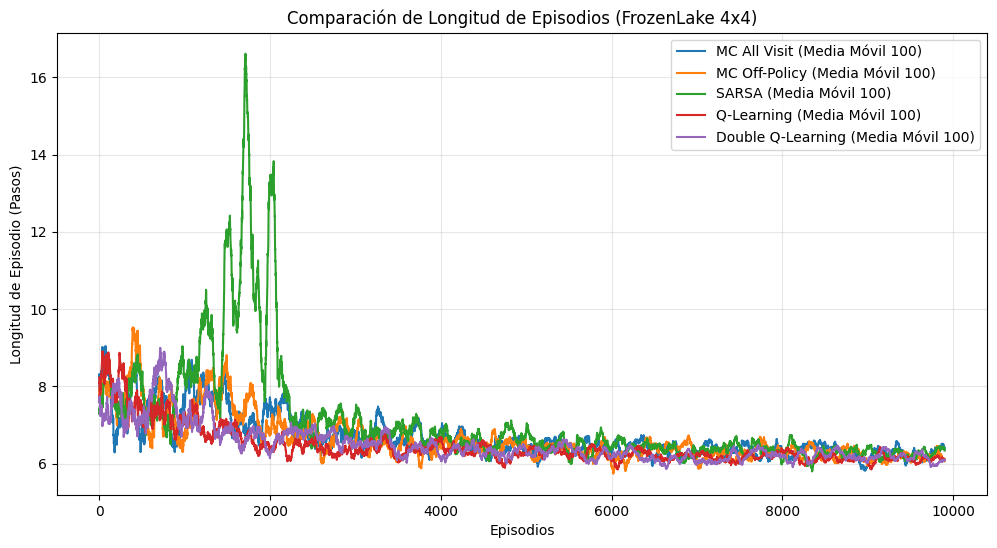

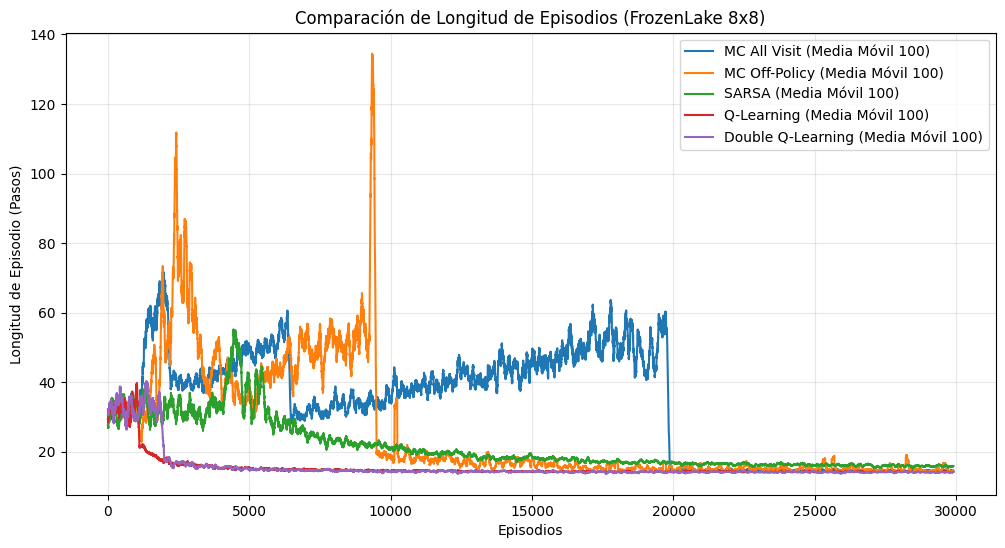

In [8]:
# Visualización: Longitud de Episodios (Suavizado)
def moving_average(a, n=100) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def plot_lengths(results, title_suffix, window_size=100):
    plt.figure(figsize=(12, 6))

    for name, data in results.items():
        lengths = data['lengths']
        # Aplicamos media móvil para suavizar la gráfica
        if len(lengths) > window_size:
            smoothed_lengths = moving_average(lengths, window_size)
            plt.plot(smoothed_lengths, label=f"{name} (Media Móvil {window_size})")
        else:
            plt.plot(lengths, label=name, alpha=0.5)

    plt.xlabel('Episodios')
    plt.ylabel('Longitud de Episodio (Pasos)')
    plt.title(f'Comparación de Longitud de Episodios ({title_suffix})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot 4x4
plot_lengths(results_4x4, "FrozenLake 4x4", window_size=100)

# Plot 8x8
plot_lengths(results_8x8, "FrozenLake 8x8", window_size=100)

# Comparativa en MountainCar-v0 (Métodos Aproximados)

En esta sección, comparamos algoritmos que utilizan aproximación de funciones para resolver el entorno continuo **MountainCar-v0**.
Utilizamos **Tile Coding** para discretizar el espacio de estados.

Algoritmos comparados:
1.  **Semi-Gradient SARSA**: SARSA con aproximación lineal.
2.  **Deep Q-Learning**: Q-Learning con redes neuronales.
3.  **Double Deep Q-Learning**: Variante de Deep Q-Learning para reducir sobreestimación.

Los resultados de entrenamiento de estos algoritmos han sido pre-calculados y almacenados en un archivo CSV para facilitar su visualización y comparación directa sin necesidad de re-entrenar modelos costosos computacionalmente.


## 2. Carga y Visualización de Resultados Complejos

A continuación, cargamos los datos de `resultados_metodos_aproximados.csv` (o similar) para reconstruir las curvas de aprendizaje.


In [14]:
# Función para cargar resultados desde CSV y formatear para plotting
def cargar_resultados_csv(filename):
    """
    Carga los resultados de un fichero CSV y los devuelve en el diccionario 'results'
    esperado por las funciones de plot_rewards y plot_lengths.
    Estructura CSV esperada columns: Algorithm, Episode, Average_Reward, Episode_Length
    """
    results = {}
    
    if not os.path.exists(filename):
        print(f"Error: El archivo {filename} no existe.")
        return results
        
    print(f"Cargando resultados de {filename}...")
    df = pd.read_csv(filename)
    
    # Obtenemos la lista de algoritmos únicos
    algorithms = df['Algorithm'].unique()
    
    for algo in algorithms:
        df_algo = df[df['Algorithm'] == algo]
        
        # Debemos asegurar que estén ordenados por episodio
        df_algo = df_algo.sort_values('Episode')
        
        stats = df_algo['Average_Reward'].values
        lengths = df_algo['Episode_Length'].values
        
        results[algo] = {
            'stats': stats, 
            'lengths': lengths
        }
        print(f" -> Cargado {algo}: {len(stats)} episodios.")
        
    return results

# Cargamos los datos
# Asumimos que el archivo generado en el otro notebook se llama "resultados_metodos_aproximados.csv"
# Si está en una subcarpeta, ajustar ruta.
filename_csv = "resultados_metodos_aproximados.csv" 
# Intento de encontrarlo si no está en la raíz
if not os.path.exists(filename_csv) and os.path.exists("Entornos_Complejos/resultados_metodos_aproximados.csv"):
     filename_csv = "Entornos_Complejos/resultados_metodos_aproximados.csv"

results_mountaincar = cargar_resultados_csv(filename_csv)


--- Iniciando experimentos para MountainCar-v0 (Aproximación de Funciones: Evaluación) ---
[MountainCar-v0] Evaluando Semi-Gradient SARSA (Entrenamiento rápido por defecto)...


Eval SG SARSA: 100%|██████████| 100/100 [00:01<00:00, 50.71it/s]


[MountainCar-v0] Evaluando Deep Q-Learning (Cargando pesos)...
Cargando pesos_DeepQL.pth...


Evaluando AgenteDT_DeepQL: 100%|██████████| 100/100 [00:02<00:00, 39.58it/s]


[MountainCar-v0] Evaluando Double Deep Q-Learning (Cargando pesos)...
No existe pesos_DoubleDeepQL.pth, intentando con pesos_DeepQL.pth como fallback...


Evaluando AgenteDT_DobleDeepQL: 100%|██████████| 100/100 [00:02<00:00, 37.85it/s]


## 3. Análisis de Resultados en Continuous State Space

De igual forma que para FrozenLake, comparamos curvas de:
1.  **Recompensa Acumulada**: Indicaría la velocidad de convergencia o estabilidad de la solución.
2.  **Longitud de Episodios**: Métrica crítica en *MountainCar*, donde menos pasos significan que el coche sale más rápido del valle.

Estos gráficos muestran la eficiencia comparativa de los tres métodos aproximados.


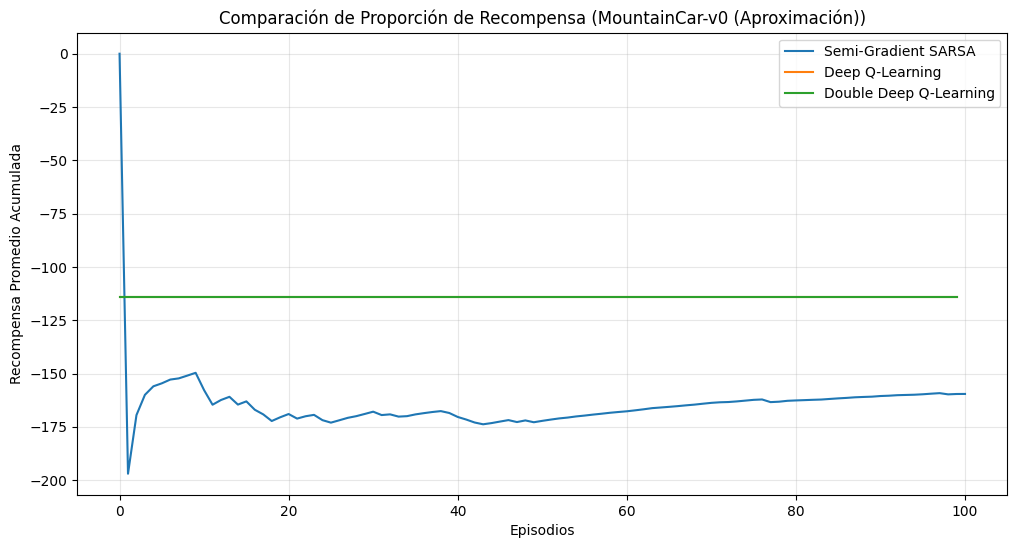

Rendimiento final (Promedio Acumulado) - MountainCar-v0 (Aproximación):
Semi-Gradient SARSA: -159.5800
Deep Q-Learning: -114.0000
Double Deep Q-Learning: -114.0000


TypeError: plot_lengths() takes 1 positional argument but 2 were given

In [15]:
# Visualización de Resultados para MountainCar (Solo si resultados cargados)
if results_mountaincar:
    plot_rewards(results_mountaincar, "MountainCar-v0 (Aproximación)")
    plot_lengths(results_mountaincar, "MountainCar-v0 (Aproximación)")
else:
    print("No hay datos para mostrar.")